In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

columns = ['y'] + [f'x{i+1}' for i in range(len(x_column))]
final_df = pd.DataFrame(rows, columns=columns)

print(final_df.head())

     y        x1        x2        x3        x4        x5        x6        x7  \
0  0.1  96.42178  96.73526  97.08696  97.48573  97.90762  98.30242  98.61735   
1  0.1  94.88798  94.77357  94.57670  94.37805  94.23810  94.18996  94.24100   
2  0.1  93.81363  94.48710  94.91174  95.08084  95.02625  94.81781  94.55362   
3  0.0  96.55682  96.94276  97.27303  97.54424  97.74432  97.86996  97.94167   
4  0.0  99.31718  99.34827  99.38692  99.45122  99.53219  99.60973  99.67068   

         x8        x9  ...     x7459     x7460     x7461     x7462     x7463  \
0  98.82209  98.92204  ...  88.13792  88.14457  88.14877  88.14815  88.14097   
1  94.38189  94.59738  ...  86.48448  86.49870  86.51332  86.52503  86.53049   
2  94.33720  94.25089  ...  83.75468  83.77602  83.79831  83.81705  83.82767   
3  98.00403  98.11266  ...  84.39698  84.40326  84.40857  84.41041  84.40598   
4  99.71947  99.77927  ...  87.44954  87.46559  87.48314  87.49653  87.50082   

      x7464     x7465     x7466     x7

In [3]:
y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]
print(X.head())

         x1        x2        x3        x4        x5        x6        x7  \
0  96.42178  96.73526  97.08696  97.48573  97.90762  98.30242  98.61735   
1  94.88798  94.77357  94.57670  94.37805  94.23810  94.18996  94.24100   
2  93.81363  94.48710  94.91174  95.08084  95.02625  94.81781  94.55362   
3  96.55682  96.94276  97.27303  97.54424  97.74432  97.86996  97.94167   
4  99.31718  99.34827  99.38692  99.45122  99.53219  99.60973  99.67068   

         x8        x9       x10  ...     x7459     x7460     x7461     x7462  \
0  98.82209  98.92204  98.95562  ...  88.13792  88.14457  88.14877  88.14815   
1  94.38189  94.59738  94.87569  ...  86.48448  86.49870  86.51332  86.52503   
2  94.33720  94.25089  94.33616  ...  83.75468  83.77602  83.79831  83.81705   
3  98.00403  98.11266  98.31223  ...  84.39698  84.40326  84.40857  84.41041   
4  99.71947  99.77927  99.88290  ...  87.44954  87.46559  87.48314  87.49653   

      x7463     x7464     x7465     x7466     x7467     x7468  
0  8

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
print(y_train)

16    0.7
5     0.0
13    0.8
11    0.9
24    0.4
1     0.1
2     0.1
29    0.3
3     0.0
27    0.3
23    0.5
30    0.2
22    0.5
18    0.6
25    0.4
6     1.0
20    0.6
32    0.2
7     1.0
10    0.9
14    0.8
28    0.3
Name: y, dtype: float64


In [5]:
pls2 = PLSRegression(n_components=4);
pls2.fit(X_train, y_train); 
print("trainR^2 =",pls2.score(X_train, y_train))

trainR^2 = 0.9288557204995569


In [6]:
print("testR^2 =",pls2.score(X_test, y_test))

testR^2 = 0.9436925955104489


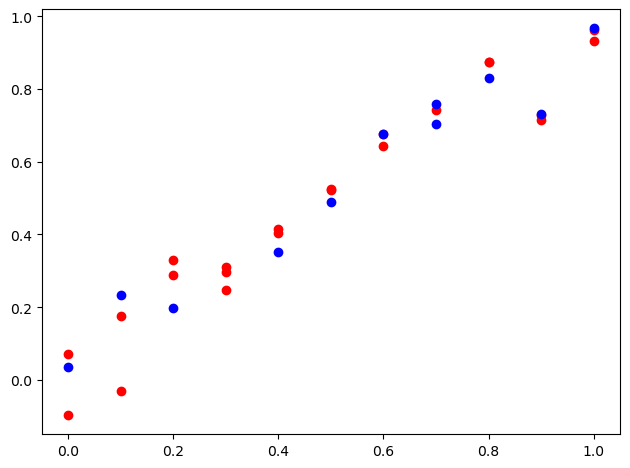

In [7]:
y_pred = pls2.predict(X_train)
plt.scatter (y_train, y_pred, color='red')
plt.tight_layout()
y_predtest = pls2.predict(X_test)
plt.scatter (y_test, y_predtest, color='blue')
plt.show()

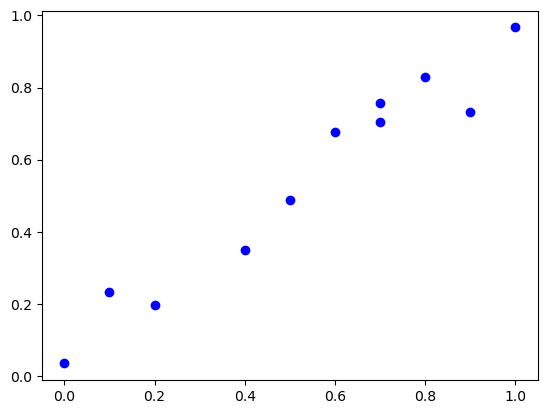

In [8]:
y_predtest = pls2.predict(X_test)
plt.scatter (y_test, y_predtest, color='blue')
plt.show()

trainR^2 = 0.4777594019840117
testR^2 = 0.38148906718363707


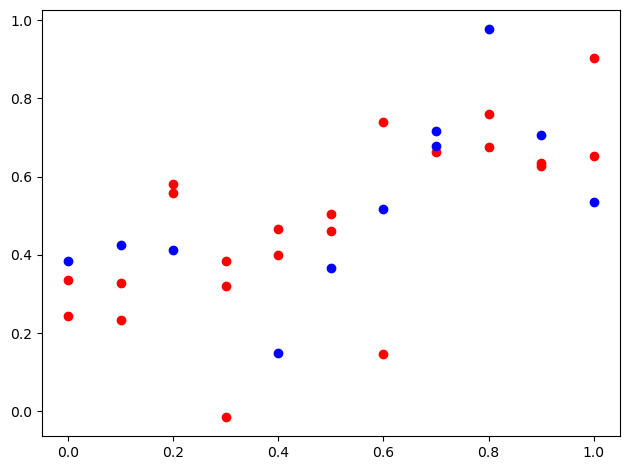

trainR^2 = 0.8493333050383046
testR^2 = 0.8652939090440215


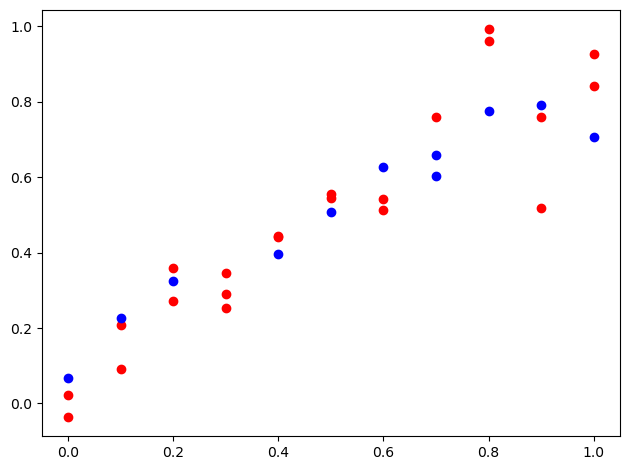

trainR^2 = 0.9110317810952705
testR^2 = 0.9101190939902951


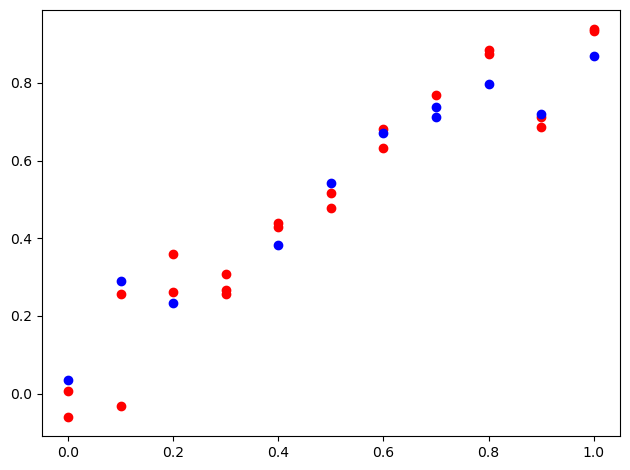

trainR^2 = 0.9288557204995569
testR^2 = 0.9436925955104489


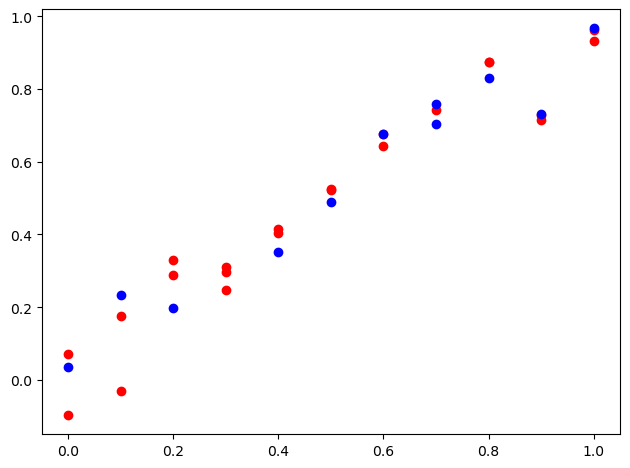

trainR^2 = 0.942688650134636
testR^2 = 0.9294013619325789


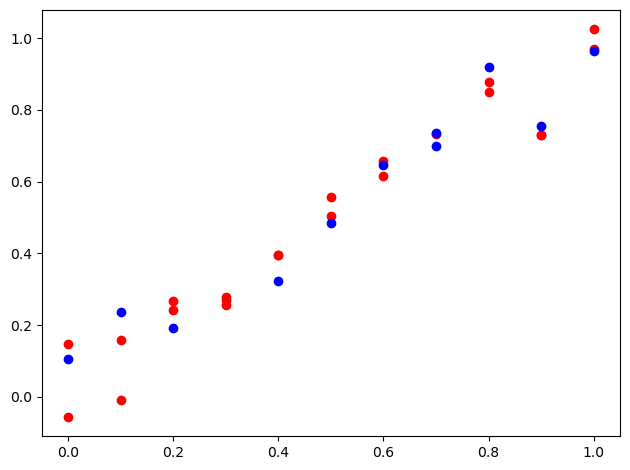

trainR^2 = 0.9701617155429404
testR^2 = 0.8764249835905082


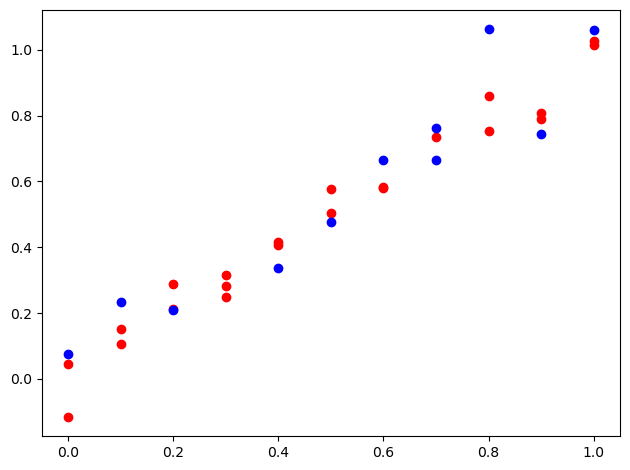

trainR^2 = 0.9815988928422033
testR^2 = 0.8369007612071493


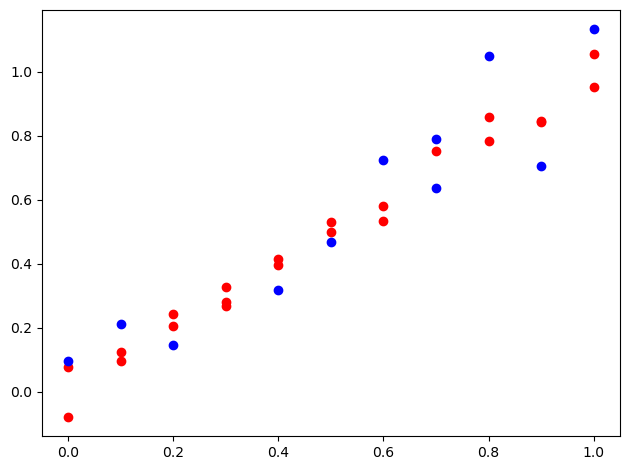

trainR^2 = 0.993920264444701
testR^2 = 0.7933290035293868


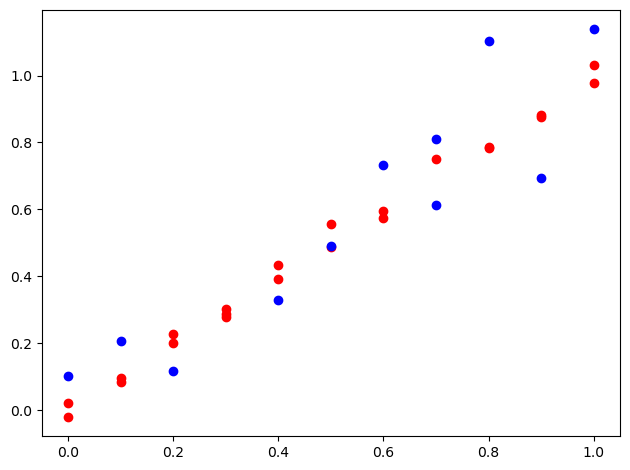

trainR^2 = 0.9967295513338388
testR^2 = 0.7969446656248583


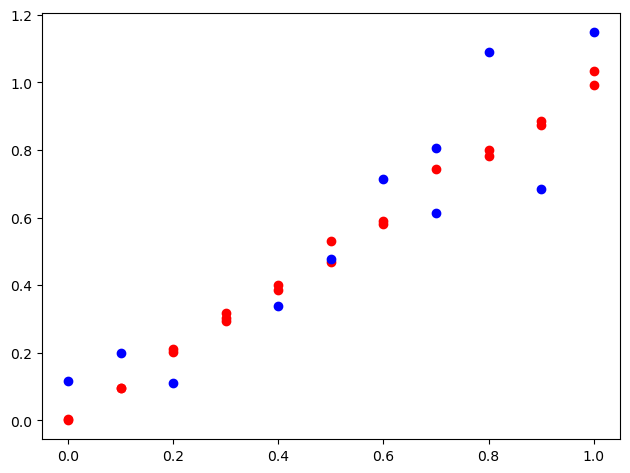

trainR^2 = 0.9992481323640141
testR^2 = 0.7933598729173503


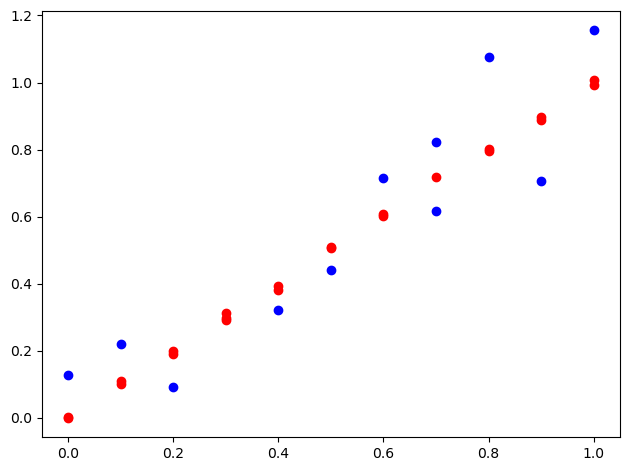

     x         y
0  1.0  0.381489
1  2.0  0.865294
2  3.0  0.910119
3  4.0  0.943693
4  5.0  0.929401
      x         y
5   6.0  0.876425
6   7.0  0.836901
7   8.0  0.793329
8   9.0  0.796945
9  10.0  0.793360


In [9]:
r2data = []
for i in range(10):
    pls2 = PLSRegression(n_components=i+1);
    pls2.fit(X_train, y_train)
    print("trainR^2 =",pls2.score(X_train, y_train))
    print("testR^2 =",pls2.score(X_test, y_test))
    y_pred = pls2.predict(X_train)
    plt.scatter (y_train, y_pred, color='red')
    plt.tight_layout()
    y_predtest = pls2.predict(X_test)
    plt.scatter (y_test, y_predtest, color='blue')
    plt.show()
    r2insert = np.insert(pls2.score(X_test, y_test), 0, i+1)
    r2data.append(r2insert)
columns = ['x']+ ['y']
final_df_r2 = pd.DataFrame(r2data, columns=columns)
print(final_df_r2.head())
print(final_df_r2.tail())

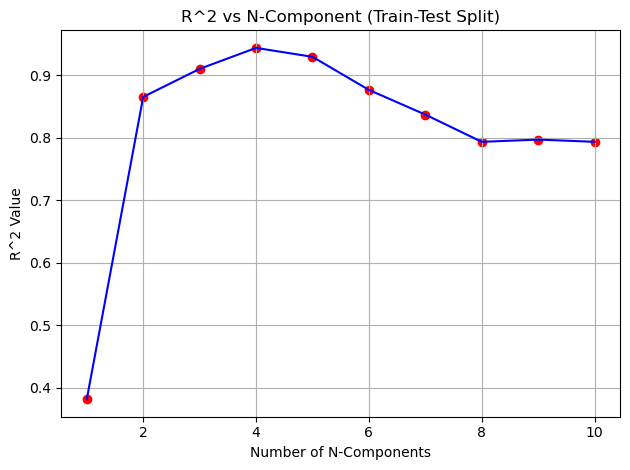

In [10]:
X = final_df_r2.iloc[:, 0]
y = final_df_r2.iloc[:, 1:]
plt.scatter (X,y, color='red')
plt.plot (X, y, color='blue')
plt.xlabel('Number of N-Components')
plt.ylabel('R^2 Value')
plt.title('R^2 vs N-Component (Train-Test Split)')
plt.tight_layout()
plt.grid(True)
plt.show()

KFold(n_splits=5, random_state=42, shuffle=True)
N-Components: 1, Mean CV R^2: 0.2339
N-Components: 2, Mean CV R^2: 0.7946
N-Components: 3, Mean CV R^2: 0.8714
N-Components: 4, Mean CV R^2: 0.8842
N-Components: 5, Mean CV R^2: 0.8749
N-Components: 6, Mean CV R^2: 0.8386
N-Components: 7, Mean CV R^2: 0.8055
N-Components: 8, Mean CV R^2: 0.7677
N-Components: 9, Mean CV R^2: 0.7535
N-Components: 10, Mean CV R^2: 0.7511


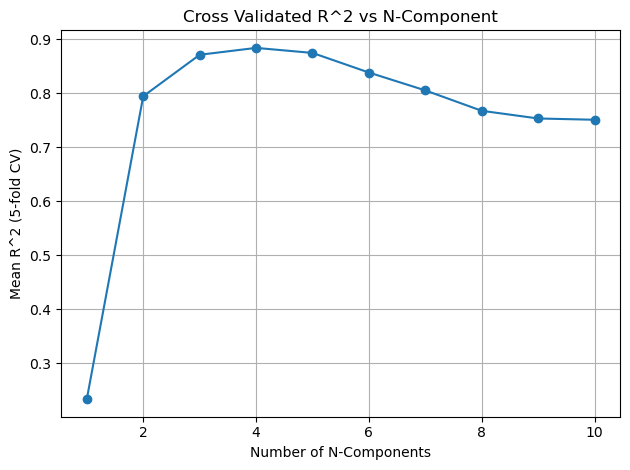

In [11]:
X = final_df.iloc[:, 1:]
y = final_df.iloc[:, 0]

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

max_components = 10
k = 5 
r2_cv_scores = []

kf = KFold(n_splits=k, shuffle=True, random_state=42)
print(kf)
for n_comp in range(1, max_components + 1):
    fold_scores = []
    
    for train_index, val_index in kf.split(X):
        X_train_kf, X_val_kf = X.iloc[train_index], X.iloc[val_index]
        y_train_kf, y_val_kf = y.iloc[train_index], y.iloc[val_index]

        pls = PLSRegression(n_components=n_comp)
        pls.fit(X_train_kf, y_train_kf)
        y_pred_kf = pls.predict(X_val_kf)
        score = r2_score(y_val_kf, y_pred_kf)
        fold_scores.append(score)
    
    mean_score = np.mean(fold_scores)
    r2_cv_scores.append((n_comp, mean_score))
    print(f"N-Components: {n_comp}, Mean CV R^2: {mean_score:.4f}")

r2_df = pd.DataFrame(r2_cv_scores, columns=['n_components', 'mean_r2'])
plt.plot(r2_df['n_components'], r2_df['mean_r2'], marker='o')
plt.xlabel('Number of N-Components')
plt.ylabel('Mean R^2 (5-fold CV)')
plt.title('Cross Validated R^2 vs N-Component')
plt.grid(True)
plt.tight_layout()
plt.show()

K: 3, GroupKFold N-Components: 1, Mean CV RMSE: 0.2728
K: 3, GroupKFold N-Components: 2, Mean CV RMSE: 0.1462
K: 3, GroupKFold N-Components: 3, Mean CV RMSE: 0.1126
K: 3, GroupKFold N-Components: 4, Mean CV RMSE: 0.1138
K: 3, GroupKFold N-Components: 5, Mean CV RMSE: 0.1032
K: 3, GroupKFold N-Components: 6, Mean CV RMSE: 0.1045
K: 3, GroupKFold N-Components: 7, Mean CV RMSE: 0.1194
K: 3, GroupKFold N-Components: 8, Mean CV RMSE: 0.1158
K: 3, GroupKFold N-Components: 9, Mean CV RMSE: 0.1166
K: 3, GroupKFold N-Components: 10, Mean CV RMSE: 0.1183


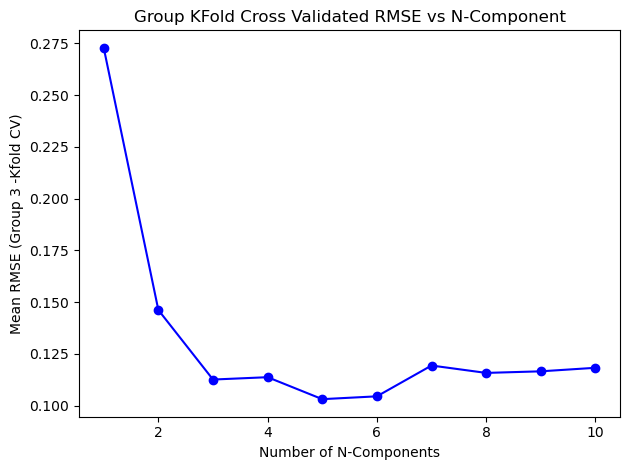

K: 5, GroupKFold N-Components: 1, Mean CV RMSE: 0.2659
K: 5, GroupKFold N-Components: 2, Mean CV RMSE: 0.1370
K: 5, GroupKFold N-Components: 3, Mean CV RMSE: 0.1184
K: 5, GroupKFold N-Components: 4, Mean CV RMSE: 0.1187
K: 5, GroupKFold N-Components: 5, Mean CV RMSE: 0.1222
K: 5, GroupKFold N-Components: 6, Mean CV RMSE: 0.1251
K: 5, GroupKFold N-Components: 7, Mean CV RMSE: 0.1288
K: 5, GroupKFold N-Components: 8, Mean CV RMSE: 0.1337
K: 5, GroupKFold N-Components: 9, Mean CV RMSE: 0.1273
K: 5, GroupKFold N-Components: 10, Mean CV RMSE: 0.1283


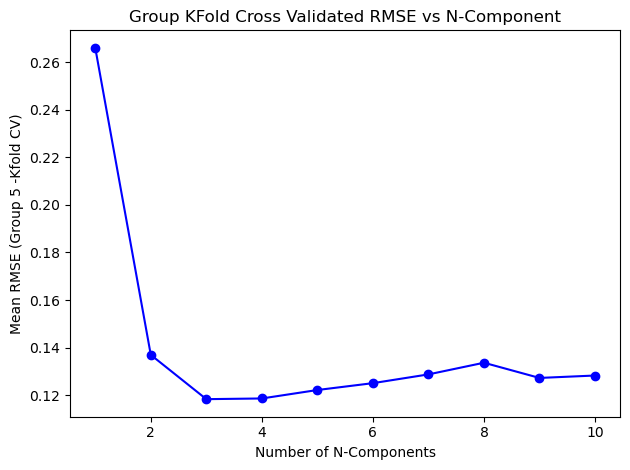

K: 7, GroupKFold N-Components: 1, Mean CV RMSE: 0.2219
K: 7, GroupKFold N-Components: 2, Mean CV RMSE: 0.1205
K: 7, GroupKFold N-Components: 3, Mean CV RMSE: 0.1038
K: 7, GroupKFold N-Components: 4, Mean CV RMSE: 0.1087
K: 7, GroupKFold N-Components: 5, Mean CV RMSE: 0.1021
K: 7, GroupKFold N-Components: 6, Mean CV RMSE: 0.1071
K: 7, GroupKFold N-Components: 7, Mean CV RMSE: 0.1163
K: 7, GroupKFold N-Components: 8, Mean CV RMSE: 0.1225
K: 7, GroupKFold N-Components: 9, Mean CV RMSE: 0.1179
K: 7, GroupKFold N-Components: 10, Mean CV RMSE: 0.1085


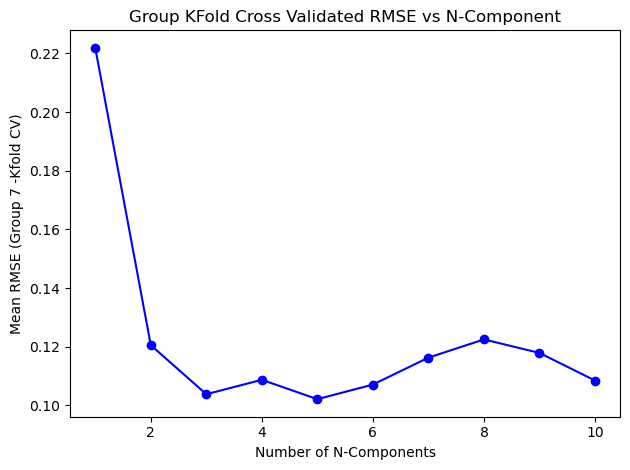

K: 9, GroupKFold N-Components: 1, Mean CV RMSE: 0.2251
K: 9, GroupKFold N-Components: 2, Mean CV RMSE: 0.1237
K: 9, GroupKFold N-Components: 3, Mean CV RMSE: 0.0984
K: 9, GroupKFold N-Components: 4, Mean CV RMSE: 0.1061
K: 9, GroupKFold N-Components: 5, Mean CV RMSE: 0.0993
K: 9, GroupKFold N-Components: 6, Mean CV RMSE: 0.1047
K: 9, GroupKFold N-Components: 7, Mean CV RMSE: 0.1104
K: 9, GroupKFold N-Components: 8, Mean CV RMSE: 0.1211
K: 9, GroupKFold N-Components: 9, Mean CV RMSE: 0.1145
K: 9, GroupKFold N-Components: 10, Mean CV RMSE: 0.1104


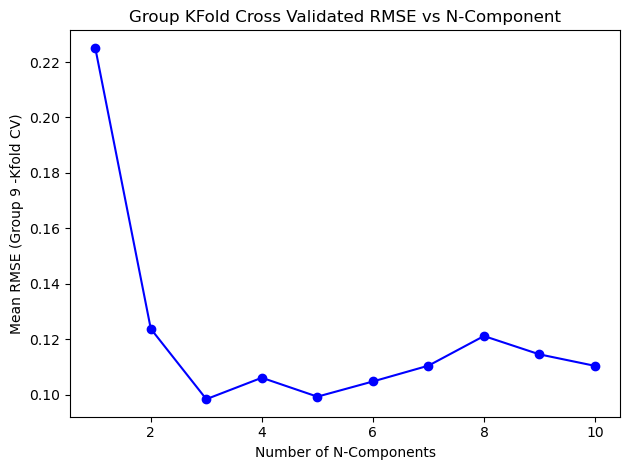

In [44]:
from sklearn.metrics import root_mean_squared_error
groups = [i // 3 for i in range(len(files))]  
from sklearn.model_selection import GroupKFold

max_components = 10
#k = 5
#r2_cv_scores = []
#color = ['red', 'blue', 'green', 'yellow']
#gkf = GroupKFold(n_splits=k)
for k in [3, 5, 7, 9]:
    rmse_cv_scores = []
    plt.figure()
    gkf = GroupKFold(n_splits=k)
    for n_comp in range(1, max_components + 1):
        fold_scores = []
        for train_index, val_index in gkf.split(X, y, groups):
            X_train_gkf, X_val_gkf = X.iloc[train_index], X.iloc[val_index]
            y_train_gkf, y_val_gkf = y.iloc[train_index], y.iloc[val_index]
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train_gkf, y_train_gkf)
            y_pred_gkf = pls.predict(X_val_gkf)
            score = root_mean_squared_error(y_val_gkf, y_pred_gkf)
            fold_scores.append(score)
        mean_score = np.mean(fold_scores)
        rmse_cv_scores.append((n_comp, mean_score))
        print(f"K: {k}, GroupKFold N-Components: {n_comp}, Mean CV RMSE: {mean_score:.4f}")
    rmse_df = pd.DataFrame(rmse_cv_scores, columns=['n_components', 'mean_rmse'])
    plt.plot(rmse_df['n_components'], rmse_df['mean_rmse'], marker='o', color= 'blue')
    plt.xlabel('Number of N-Components')
    plt.ylabel(f'Mean RMSE (Group {k} -Kfold CV)')
    plt.title('Group KFold Cross Validated RMSE vs N-Component')
    #plt.grid(True)
    plt.tight_layout()
    plt.show()


K: 3, GroupKFold N-Components: 1, Mean CV MAE: 0.2157
K: 3, GroupKFold N-Components: 2, Mean CV MAE: 0.1112
K: 3, GroupKFold N-Components: 3, Mean CV MAE: 0.0933
K: 3, GroupKFold N-Components: 4, Mean CV MAE: 0.0985
K: 3, GroupKFold N-Components: 5, Mean CV MAE: 0.0887
K: 3, GroupKFold N-Components: 6, Mean CV MAE: 0.0893
K: 3, GroupKFold N-Components: 7, Mean CV MAE: 0.0982
K: 3, GroupKFold N-Components: 8, Mean CV MAE: 0.0969
K: 3, GroupKFold N-Components: 9, Mean CV MAE: 0.0964
K: 3, GroupKFold N-Components: 10, Mean CV MAE: 0.0980


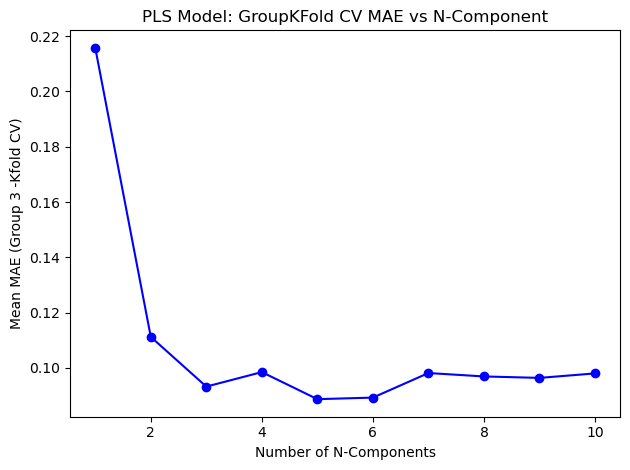

K: 5, GroupKFold N-Components: 1, Mean CV MAE: 0.2196
K: 5, GroupKFold N-Components: 2, Mean CV MAE: 0.1032
K: 5, GroupKFold N-Components: 3, Mean CV MAE: 0.0959
K: 5, GroupKFold N-Components: 4, Mean CV MAE: 0.0977
K: 5, GroupKFold N-Components: 5, Mean CV MAE: 0.0976
K: 5, GroupKFold N-Components: 6, Mean CV MAE: 0.1023
K: 5, GroupKFold N-Components: 7, Mean CV MAE: 0.1000
K: 5, GroupKFold N-Components: 8, Mean CV MAE: 0.1059
K: 5, GroupKFold N-Components: 9, Mean CV MAE: 0.0983
K: 5, GroupKFold N-Components: 10, Mean CV MAE: 0.1007


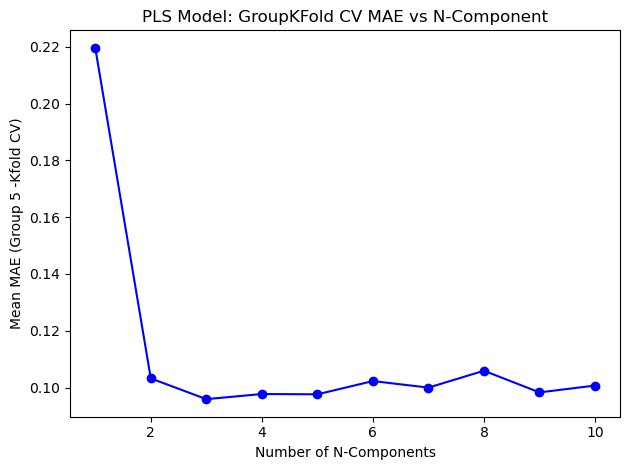

K: 7, GroupKFold N-Components: 1, Mean CV MAE: 0.1890
K: 7, GroupKFold N-Components: 2, Mean CV MAE: 0.1033
K: 7, GroupKFold N-Components: 3, Mean CV MAE: 0.0889
K: 7, GroupKFold N-Components: 4, Mean CV MAE: 0.0900
K: 7, GroupKFold N-Components: 5, Mean CV MAE: 0.0861
K: 7, GroupKFold N-Components: 6, Mean CV MAE: 0.0956
K: 7, GroupKFold N-Components: 7, Mean CV MAE: 0.1012
K: 7, GroupKFold N-Components: 8, Mean CV MAE: 0.1054
K: 7, GroupKFold N-Components: 9, Mean CV MAE: 0.1021
K: 7, GroupKFold N-Components: 10, Mean CV MAE: 0.0960


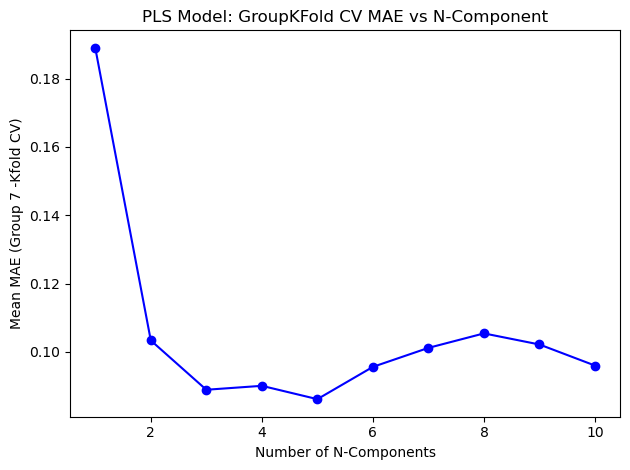

K: 9, GroupKFold N-Components: 1, Mean CV MAE: 0.2027
K: 9, GroupKFold N-Components: 2, Mean CV MAE: 0.1085
K: 9, GroupKFold N-Components: 3, Mean CV MAE: 0.0895
K: 9, GroupKFold N-Components: 4, Mean CV MAE: 0.0928
K: 9, GroupKFold N-Components: 5, Mean CV MAE: 0.0902
K: 9, GroupKFold N-Components: 6, Mean CV MAE: 0.0967
K: 9, GroupKFold N-Components: 7, Mean CV MAE: 0.1012
K: 9, GroupKFold N-Components: 8, Mean CV MAE: 0.1080
K: 9, GroupKFold N-Components: 9, Mean CV MAE: 0.1056
K: 9, GroupKFold N-Components: 10, Mean CV MAE: 0.1021


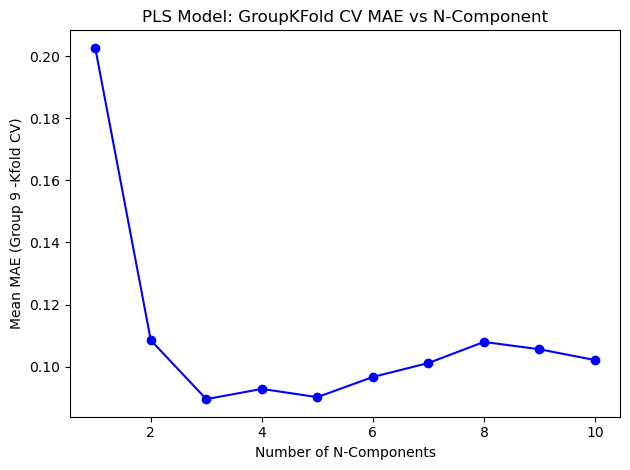

In [12]:
from sklearn.metrics import mean_absolute_error
groups = [i // 3 for i in range(len(files))]  
from sklearn.model_selection import GroupKFold

max_components = 10
#k = 5
#r2_cv_scores = []
#color = ['red', 'blue', 'green', 'yellow']
#gkf = GroupKFold(n_splits=k)
for k in [3, 5, 7, 9]:
    mae_cv_scores = []
    plt.figure()
    gkf = GroupKFold(n_splits=k)
    for n_comp in range(1, max_components + 1):
        fold_scores = []
        for train_index, val_index in gkf.split(X, y, groups):
            X_train_gkf, X_val_gkf = X.iloc[train_index], X.iloc[val_index]
            y_train_gkf, y_val_gkf = y.iloc[train_index], y.iloc[val_index]
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train_gkf, y_train_gkf)
            y_pred_gkf = pls.predict(X_val_gkf)
            score = mean_absolute_error(y_val_gkf, y_pred_gkf)
            fold_scores.append(score)
        mean_score = np.mean(fold_scores)
        mae_cv_scores.append((n_comp, mean_score))
        print(f"K: {k}, GroupKFold N-Components: {n_comp}, Mean CV MAE: {mean_score:.4f}")
    mae_df = pd.DataFrame(mae_cv_scores, columns=['n_components', 'mean_mae'])
    plt.plot(mae_df['n_components'], mae_df['mean_mae'], marker='o', color= 'blue')
    plt.xlabel('Number of N-Components')
    plt.ylabel(f'Mean MAE (Group {k} -Kfold CV)')
    plt.title('PLS Model: GroupKFold CV MAE vs N-Component')
    plt.tight_layout()
    plt.show()


n_components=1, k=3, Mean RMSE: 0.2728
n_components=1, k=5, Mean RMSE: 0.2659
n_components=1, k=7, Mean RMSE: 0.2219
n_components=1, k=9, Mean RMSE: 0.2251
n_components=1, Overall Avg RMSE across k=3,5,7,9: 0.2464
n_components=2, k=3, Mean RMSE: 0.1462
n_components=2, k=5, Mean RMSE: 0.1370
n_components=2, k=7, Mean RMSE: 0.1205
n_components=2, k=9, Mean RMSE: 0.1237
n_components=2, Overall Avg RMSE across k=3,5,7,9: 0.1319
n_components=3, k=3, Mean RMSE: 0.1126
n_components=3, k=5, Mean RMSE: 0.1184
n_components=3, k=7, Mean RMSE: 0.1038
n_components=3, k=9, Mean RMSE: 0.0984
n_components=3, Overall Avg RMSE across k=3,5,7,9: 0.1083
n_components=4, k=3, Mean RMSE: 0.1138
n_components=4, k=5, Mean RMSE: 0.1187
n_components=4, k=7, Mean RMSE: 0.1087
n_components=4, k=9, Mean RMSE: 0.1061
n_components=4, Overall Avg RMSE across k=3,5,7,9: 0.1118
n_components=5, k=3, Mean RMSE: 0.1032
n_components=5, k=5, Mean RMSE: 0.1222
n_components=5, k=7, Mean RMSE: 0.1021
n_components=5, k=9, Mean R

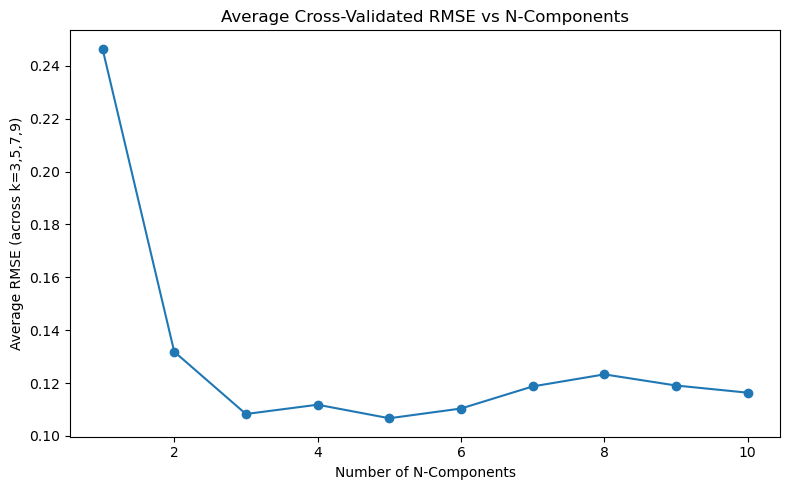

In [8]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import root_mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

groups = [i // 3 for i in range(len(files))] 
max_components = 10

final_scores = [] 

for n_comp in range(1, max_components + 1):
    rmse_for_k = [] 
    
    for k in [3, 5, 7, 9]:
        gkf = GroupKFold(n_splits=k)
        fold_rmses = []
        
        for train_index, val_index in gkf.split(X, y, groups):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            y_pred = pls.predict(X_val)
            
            rmse = root_mean_squared_error(y_val, y_pred)
            fold_rmses.append(rmse)
        
        mean_rmse_k = np.mean(fold_rmses)
        print(f"n_components={n_comp}, k={k}, Mean RMSE: {mean_rmse_k:.4f}")
        rmse_for_k.append(mean_rmse_k)
    
    overall_avg_rmse = np.mean(rmse_for_k)
    print(f"n_components={n_comp}, Overall Avg RMSE across k=3,5,7,9: {overall_avg_rmse:.4f}")
    final_scores.append((n_comp, overall_avg_rmse))
final_df = pd.DataFrame(final_scores, columns=['n_components', 'avg_rmse'])

plt.figure(figsize=(8,5))
plt.plot(final_df['n_components'], final_df['avg_rmse'], marker='o')
plt.xlabel('Number of N-Components')
plt.ylabel('Average RMSE (across k=3,5,7,9)')
plt.title('Average Cross-Validated RMSE vs N-Components')
plt.tight_layout()
plt.show()

n_components=1, k=3, Mean MAE: 0.2157
n_components=1, k=5, Mean MAE: 0.2196
n_components=1, k=7, Mean MAE: 0.1890
n_components=1, k=9, Mean MAE: 0.2027
n_components=1, Overall Avg MAE across k=3,5,7,9: 0.2068
n_components=2, k=3, Mean MAE: 0.1112
n_components=2, k=5, Mean MAE: 0.1032
n_components=2, k=7, Mean MAE: 0.1033
n_components=2, k=9, Mean MAE: 0.1085
n_components=2, Overall Avg MAE across k=3,5,7,9: 0.1066
n_components=3, k=3, Mean MAE: 0.0933
n_components=3, k=5, Mean MAE: 0.0959
n_components=3, k=7, Mean MAE: 0.0889
n_components=3, k=9, Mean MAE: 0.0895
n_components=3, Overall Avg MAE across k=3,5,7,9: 0.0919
n_components=4, k=3, Mean MAE: 0.0985
n_components=4, k=5, Mean MAE: 0.0977
n_components=4, k=7, Mean MAE: 0.0900
n_components=4, k=9, Mean MAE: 0.0928
n_components=4, Overall Avg MAE across k=3,5,7,9: 0.0948
n_components=5, k=3, Mean MAE: 0.0887
n_components=5, k=5, Mean MAE: 0.0976
n_components=5, k=7, Mean MAE: 0.0861
n_components=5, k=9, Mean MAE: 0.0902
n_components

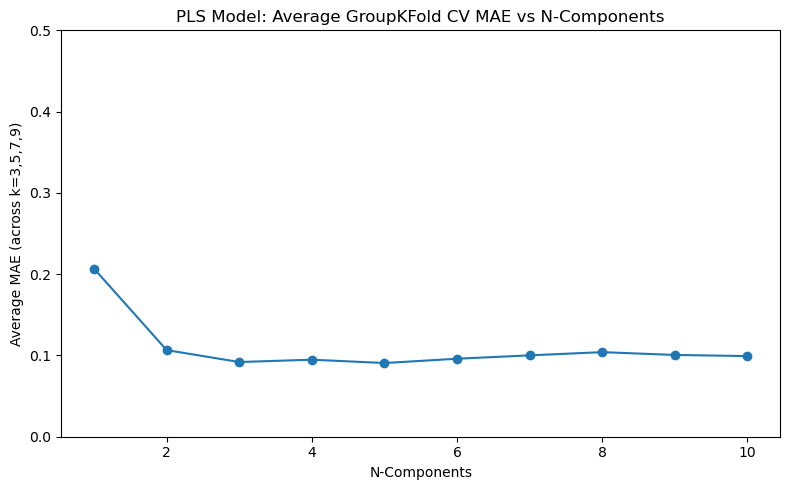

In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

groups = [i // 3 for i in range(len(files))] 
max_components = 10

final_scores = [] 

for n_comp in range(1, max_components + 1):
    mae_for_k = [] 
    
    for k in [3, 5, 7, 9]:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_index, val_index in gkf.split(X, y, groups):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, Mean MAE: {mean_mae_k:.4f}")
        mae_for_k.append(mean_mae_k)
    
    overall_avg_mae = np.mean(mae_for_k)
    print(f"n_components={n_comp}, Overall Avg MAE across k=3,5,7,9: {overall_avg_mae:.4f}")
    final_scores.append((n_comp, overall_avg_mae))
final_df = pd.DataFrame(final_scores, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(final_df['n_components'], final_df['avg_mae'], marker='o')
plt.ylim(0, 0.5)
plt.xlabel('N-Components')
plt.ylabel('Average MAE (across k=3,5,7,9)')
plt.title('PLS Model: Average GroupKFold CV MAE vs N-Components')
plt.tight_layout()
plt.show()

Found 33 calibration files
Loaded 33 spectra with 7468 features
Loaded 4 solvent spectra
Augmented dataset size: 561 samples
n_components=1, k=3, MAE=0.2487
n_components=1, k=5, MAE=0.2472
n_components=1, k=7, MAE=0.2493
n_components=1, k=9, MAE=0.2503
n_components=1, AVG MAE: 0.2489

n_components=2, k=3, MAE=0.0841
n_components=2, k=5, MAE=0.0779
n_components=2, k=7, MAE=0.0821
n_components=2, k=9, MAE=0.0788
n_components=2, AVG MAE: 0.0807

n_components=3, k=3, MAE=0.0824
n_components=3, k=5, MAE=0.0785
n_components=3, k=7, MAE=0.0769
n_components=3, k=9, MAE=0.0799
n_components=3, AVG MAE: 0.0794

n_components=4, k=3, MAE=0.0779
n_components=4, k=5, MAE=0.0796
n_components=4, k=7, MAE=0.0756
n_components=4, k=9, MAE=0.0789
n_components=4, AVG MAE: 0.0780

n_components=5, k=3, MAE=0.0804
n_components=5, k=5, MAE=0.0727
n_components=5, k=7, MAE=0.0780
n_components=5, k=9, MAE=0.0782
n_components=5, AVG MAE: 0.0773

n_components=6, k=3, MAE=0.0787
n_components=6, k=5, MAE=0.0730
n_comp

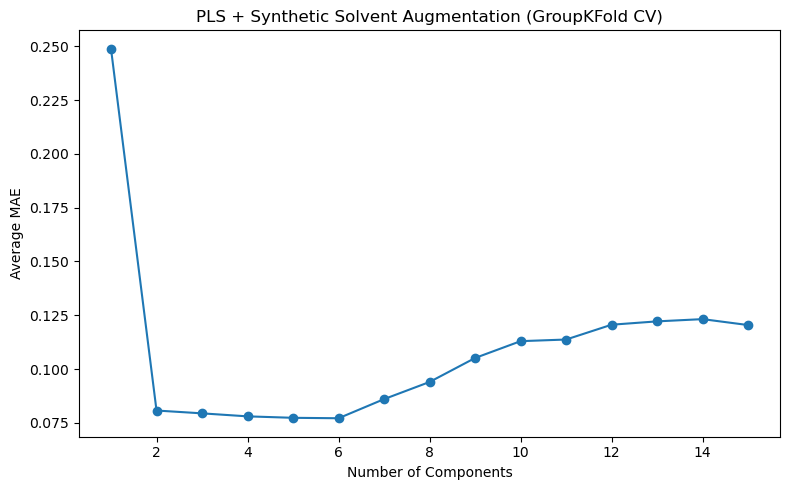

In [17]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# ==============================
# PATHS (FIX THESE IF NEEDED)
# ==============================
root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# ==============================
# CHECK PATHS
# ==============================
if not os.path.exists(root_calib):
    raise ValueError(f"Calibration folder not found: {root_calib}")

if not os.path.exists(solvent_dir):
    raise ValueError(f"Solvent folder not found: {solvent_dir}")

# ==============================
# LOAD FILES
# ==============================
calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])

if len(calib_files) == 0:
    raise ValueError("No CSV files found in calibration directory!")

calib_files = calib_files[:33]

print(f"Found {len(calib_files)} calibration files")

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

if len(calib_files) != len(y_values):
    raise ValueError("Mismatch between files and y_values!")

# ==============================
# LOAD SPECTRA
# ==============================
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

rows = []

for file, y_val in zip(calib_files, y_values):
    path = os.path.join(root_calib, file)
    
    try:
        spec = load_spectrum(path)
        if len(spec) == 0:
            print(f"Skipping empty file: {file}")
            continue
        
        row = np.insert(spec, 0, y_val)
        rows.append(row)
        
    except Exception as e:
        print(f"Error loading {file}: {e}")

# ==============================
# CRITICAL FIX
# ==============================
if len(rows) == 0:
    raise ValueError("No valid spectra loaded. Check your CSV format or paths.")

# ==============================
# ALIGN LENGTHS
# ==============================
min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i}' for i in range(min_len-1)]
df = pd.DataFrame(rows, columns=columns)

y_calib = df['y'].values
X_calib = df.drop('y', axis=1).values

n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} spectra with {n_features} features")

# ==============================
# LOAD SOLVENTS
# ==============================
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = {}

for file in solvent_files:
    path = os.path.join(solvent_dir, file)
    
    if not os.path.exists(path):
        print(f"WARNING: Missing solvent file: {file}")
        continue
    
    spec = load_spectrum(path)
    
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0,1,n_features),
                         np.linspace(0,1,len(spec)), spec)
    
    solvents[file] = spec

if len(solvents) == 0:
    raise ValueError("No solvent spectra loaded!")

print(f"Loaded {len(solvents)} solvent spectra")

# ==============================
# SYNTHETIC AUGMENTATION
# ==============================
alphas = np.arange(0.1, 0.5, 0.1)

X_all = [X_calib]
y_all = [y_calib]
groups_all = [np.arange(len(y_calib))]

def synthesize(x, solvent, alpha):
    return x + alpha * solvent

for solvent in solvents.values():
    for alpha in alphas:
        X_syn = np.array([synthesize(x, solvent, alpha) for x in X_calib])
        
        X_all.append(X_syn)
        y_all.append(y_calib)
        groups_all.append(np.arange(len(y_calib)))  # preserve grouping

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
groups = np.concatenate(groups_all)

print(f"Augmented dataset size: {len(X_all)} samples")

# ==============================
# GROUP K-FOLD CV
# ==============================
max_components = 15
k_values = [3, 5, 7, 9]

results = []

for n_comp in range(1, max_components + 1):
    mae_across_k = []
    
    for k in k_values:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_idx, val_idx in gkf.split(X_all, y_all, groups):
            X_train, X_val = X_all[train_idx], X_all[val_idx]
            y_train, y_val = y_all[train_idx], y_all[val_idx]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, MAE={mean_mae_k:.4f}")
        mae_across_k.append(mean_mae_k)
    
    avg_mae = np.mean(mae_across_k)
    print(f"n_components={n_comp}, AVG MAE: {avg_mae:.4f}\n")
    
    results.append((n_comp, avg_mae))

# ==============================
# PLOT
# ==============================
results_df = pd.DataFrame(results, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(results_df['n_components'], results_df['avg_mae'], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Average MAE')
plt.title('PLS + Synthetic Solvent Augmentation (GroupKFold CV)')
plt.tight_layout()
plt.show()